# Diabetes Prediction Using Machine Learning

## Internship Project

**Prepared By:** Jose Priyanth Shervin K

### Objective

The objective of this project is to predict whether a patient has diabetes based on medical attributes such as glucose level, BMI, age, insulin level, blood pressure, and pregnancies.

This project includes data exploration, visualization, preprocessing, machine learning model development, model evaluation, and prediction.


# 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

%matplotlib inline

# 2. Load the Dataset

The diabetes dataset is loaded into a Pandas DataFrame for further analysis.

In [3]:
df = pd.read_csv("diabetes.csv")

# 3. Dataset Overview

The dataset is explored to understand its structure, dimensions, data types, and statistical properties before analysis.

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [6]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1
767,1,93,70.0,31,102.5,30.4,0.315,23,0


In [7]:
df.shape

(768, 9)

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 4. Data Cleaning

The dataset is checked for missing values, duplicate records, and invalid zero values. In medical datasets, certain features cannot realistically have a value of zero, so these values are replaced using the median of the respective columns.

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

The dataset does not contain any missing (null) values.

In [12]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

In [13]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[columns] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### Observation

Several medical features contain zero values, which are not realistic and should be treated as missing values before building the machine learning model.

In [14]:
for column in columns:
    df[column] = df[column].replace(0, df[column].median())

In [15]:
(df[columns] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### Observation

All unrealistic zero values have been successfully replaced using the median values of their respective columns.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables and identify patterns in the diabetes dataset using visualizations.

## 5.1 Diabetes Outcome Distribution

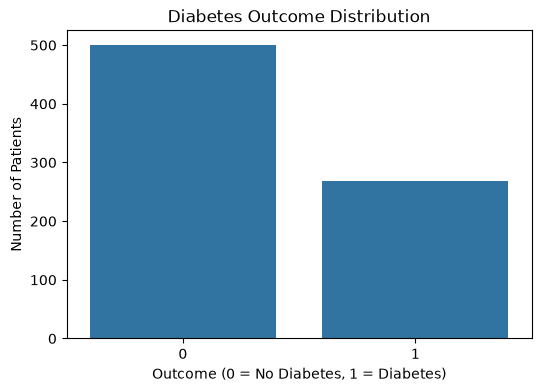

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("Number of Patients")

plt.show()

### Observation

The dataset contains both diabetic and non-diabetic patients. Non-diabetic patients are slightly more common than diabetic patients.

## 5.2 Age Distribution

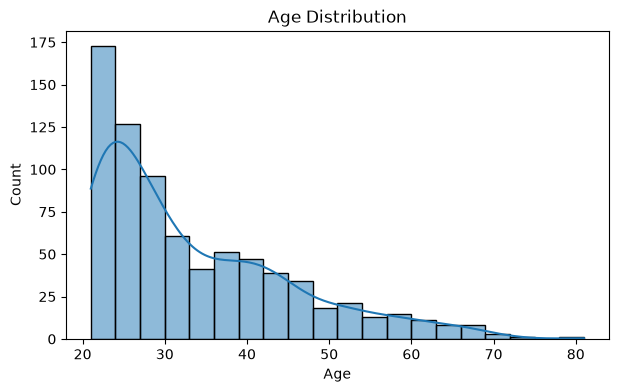

In [17]:
plt.figure(figsize=(7,4))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

### Observation

Most patients are between 20 and 40 years of age, with fewer patients in older age groups.

## 5.3 Glucose Distribution

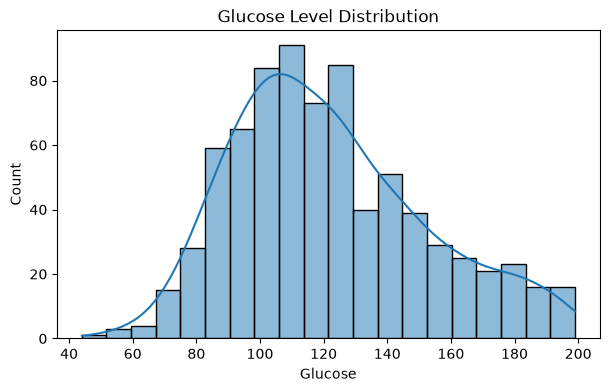

In [18]:
plt.figure(figsize=(7,4))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Level Distribution")

plt.show()

### Observation

Most glucose values are concentrated within a moderate range, while a smaller number of patients have very high glucose levels.

## 5.4 BMI Distribution

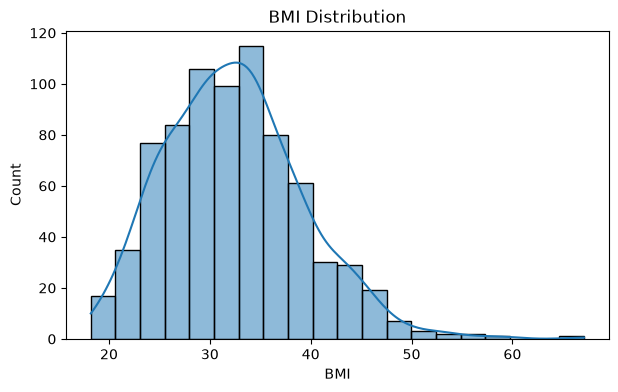

In [19]:
plt.figure(figsize=(7,4))

sns.histplot(df["BMI"], bins=20, kde=True)

plt.title("BMI Distribution")

plt.show()

### Observation

The BMI values are centered around the middle range, with a few patients having very high BMI values.

## 5.5 Blood Pressure Distribution

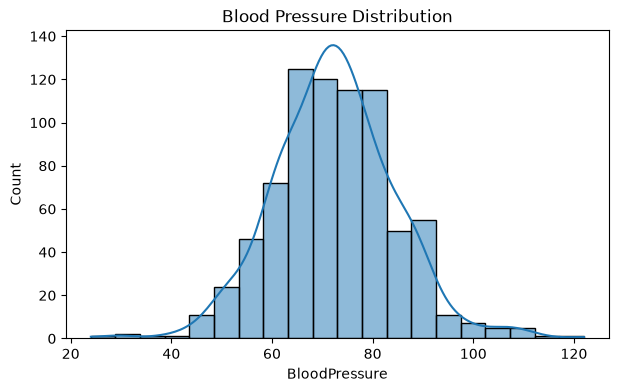

In [20]:
plt.figure(figsize=(7,4))

sns.histplot(df["BloodPressure"], bins=20, kde=True)

plt.title("Blood Pressure Distribution")

plt.show()

### Observation

Most patients have blood pressure values within a normal range, while a few patients have unusually high or low readings.

## 5.6 Diabetes Outcome Percentage

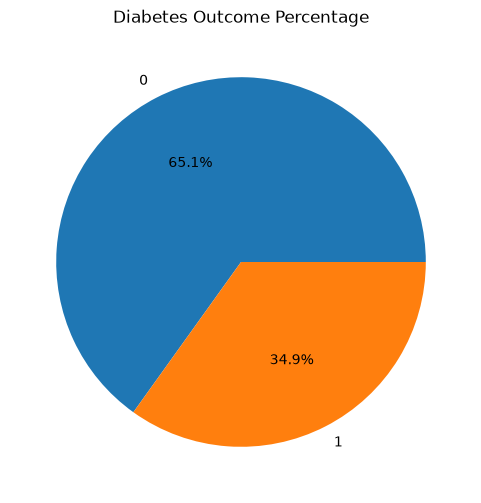

In [21]:
df["Outcome"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Diabetes Outcome Percentage")

plt.ylabel("")

plt.show()

### Observation

The pie chart shows that the majority of patients are non-diabetic, while a significant portion of the dataset consists of diabetic patients.

## 5.7 Boxplot of Glucose

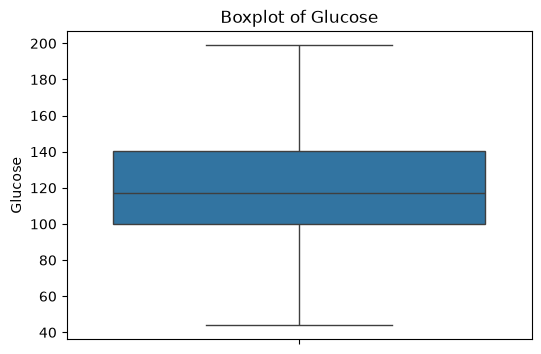

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Glucose"])

plt.title("Boxplot of Glucose")

plt.show()

### Observation

The boxplot indicates the presence of several high glucose outliers, suggesting that some patients have significantly elevated glucose levels.

# 6. Correlation Analysis

Correlation analysis measures the relationship between numerical variables. It helps identify which medical features are strongly related to diabetes and to each other.

In [23]:
correlation_matrix = df.corr()

correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


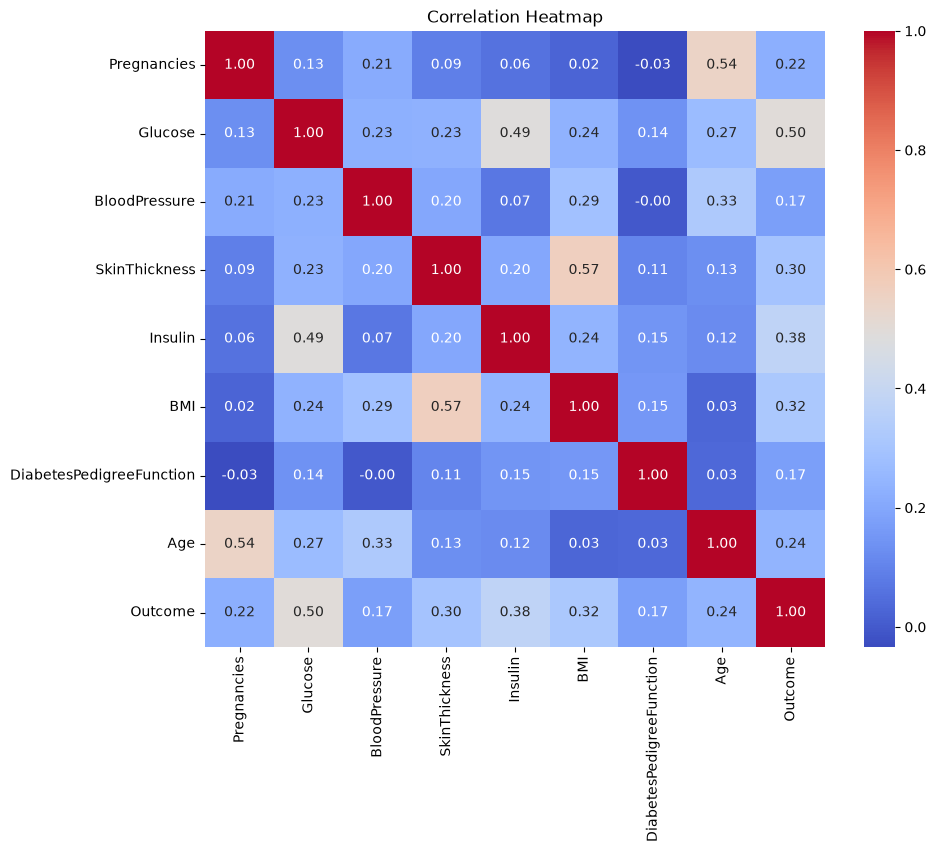

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the relationships between numerical features. Glucose has one of the strongest positive correlations with the diabetes outcome, while other features show weak to moderate correlations. This indicates that diabetes prediction depends on multiple medical factors rather than a single feature.

# 7. Data Preprocessing

Data preprocessing is performed to separate the input features and the target variable. The target variable is the value that the machine learning model will learn to predict.

In [25]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [26]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


In [27]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

# 8. Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate the model's performance on unseen data.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (614, 8)
Testing Features: (154, 8)
Training Labels: (614,)
Testing Labels: (154,)


### Observation

The dataset was successfully split into training and testing sets. Approximately 80% of the data is used to train the model, while the remaining 20% is reserved for evaluating its performance.

# 9. Model Building - Logistic Regression

A Logistic Regression model is trained using the training dataset. The model learns patterns from the input features and predicts whether a patient has diabetes.

In [30]:
model = LogisticRegression(max_iter=1000)

In [31]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [32]:
y_pred = model.predict(X_test)

In [33]:
print(y_pred[:10])

[0 0 0 0 0 1 0 0 1 1]


# 10. Model Evaluation

The performance of the Logistic Regression model is evaluated using accuracy score, confusion matrix, and classification report. These metrics help determine how well the model predicts diabetes.

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7727272727272727


### Observation

The Logistic Regression model achieved a good accuracy score, indicating that it correctly classified most patients in the testing dataset.

In [35]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[83 16]
 [19 36]]


### Observation

The confusion matrix shows the number of correct and incorrect predictions made by the model for both diabetic and non-diabetic patients.

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



### Observation

The Logistic Regression model achieved an accuracy of approximately **77%**. It performed better in identifying non-diabetic patients than diabetic patients. The classification report indicates good overall performance, while showing that diabetic cases are slightly more challenging to classify correctly.

The classification report provides detailed performance metrics such as precision, recall, F1-score, and support, offering a comprehensive evaluation of the model.

# 11. Model Building - Random Forest

A Random Forest Classifier is trained using the training dataset. Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [37]:
rf_model = RandomForestClassifier(random_state=42)

In [38]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [39]:
rf_pred = rf_model.predict(X_test)

In [40]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8831168831168831


In [41]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[88 11]
 [ 7 48]]


In [42]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.81      0.87      0.84        55

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154



### Observation

The Random Forest model achieved an accuracy of approximately **88%**, outperforming the Logistic Regression model. It demonstrated strong precision, recall, and F1-score for both diabetic and non-diabetic classes, indicating better overall predictive performance.

The Random Forest model was trained and evaluated successfully. Its performance can be compared with Logistic Regression to determine which model provides better predictions for diabetes classification.

# 12. Model Comparison

The performance of Logistic Regression and Random Forest models is compared using their accuracy scores.

In [43]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.772727
1,Random Forest,0.883117


### Observation

The comparison table shows the accuracy of both models. The model with the higher accuracy demonstrates better predictive performance on the testing dataset.

# 13. Predicting a New Patient

The trained Random Forest model is used to predict whether a new patient is diabetic or non-diabetic based on manually entered medical values.

In [46]:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [150],
    "BloodPressure": [70],
    "SkinThickness": [35],
    "Insulin": [100],
    "BMI": [32.5],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [40]
})

prediction = rf_model.predict(new_patient)

In [47]:
if prediction[0] == 1:
    print("The patient is likely Diabetic.")
else:
    print("The patient is likely Non-Diabetic.")

The patient is likely Non-Diabetic.


# 14. Conclusion

This project successfully developed a machine learning model to predict diabetes using the Pima Indians Diabetes dataset.

The dataset was explored through Exploratory Data Analysis (EDA), cleaned, and preprocessed before training machine learning models. Two classification algorithms, Logistic Regression and Random Forest, were implemented and evaluated.

Logistic Regression achieved an accuracy of approximately **77%**, while the Random Forest model achieved approximately **88%**, making it the better-performing model for this dataset.

The project demonstrates how machine learning can assist in predicting diabetes based on patient health information. Such predictive models can support healthcare professionals by providing early risk assessments, although they should complement—not replace—clinical judgment.